Preguntas a responder:

AutoML_Flaml para desempeño de modelos

In [40]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [41]:
DATA_DIR = Path.cwd().resolve().parent / "datos"

df_bank = pd.read_parquet(DATA_DIR / "02_datos_con_tipo_de_dato_ajustado_banko.parquet")

In [42]:
#y = df_bank["y"].map({'no': 0, 'yes': 1}) otra opcion
X = df_bank.drop(columns=["y"])
y = df_bank["y"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

In [43]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        45211 non-null  int64   
 1   job        45211 non-null  category
 2   marital    45211 non-null  category
 3   education  45211 non-null  category
 4   default    45211 non-null  category
 5   balance    45211 non-null  float64 
 6   housing    45211 non-null  category
 7   loan       45211 non-null  category
 8   contact    45211 non-null  category
 9   day        45211 non-null  int64   
 10  month      45211 non-null  category
 11  duration   45211 non-null  int64   
 12  campaign   45211 non-null  int64   
 13  pdays      45211 non-null  int64   
 14  previous   45211 non-null  int64   
 15  poutcome   45211 non-null  category
 16  y          45211 non-null  object  
dtypes: category(9), float64(1), int64(6), object(1)
memory usage: 3.1+ MB


In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [45]:
numeric_features = ["age", "balance", "day", "duration","campaign", "pdays","previous"]
categorical_features = ["job", "marital","default","housing","loan","contact","month","poutcome"]
ordinal_features = ["education"]


numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=[['tertiary', 'secondary', 'primary', 'unknown']]))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("ord", ordinal_transformer, ordinal_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [46]:
from flaml import AutoML
from sklearn.pipeline import Pipeline as SKLearnPipeline

automl = AutoML()

In [47]:
X_train_preprocessed = preprocessor.fit_transform(X_train)

X_test_preprocessed = preprocessor.fit_transform(X_test)

automl_settings = {
    "time_budget": 60,  # total running time in seconds
    "metric": 'accuracy',  # primary metric to optimize
    "task": 'classification',  # task type
    "estimator_list": ['lgbm', 'xgboost', 'lrl1', 'rf'],  # list of ML learners
    "log_file_name": 'flaml_banco_automl.log',  # flaml log file
    "seed": 42
}

automl.fit(X_train_preprocessed, y_train, **automl_settings)

[flaml.automl.logger: 11-03 14:51:51] {1752} INFO - task = classification
[flaml.automl.logger: 11-03 14:51:51] {1763} INFO - Evaluation method: holdout
[flaml.automl.logger: 11-03 14:51:51] {1862} INFO - Minimizing error metric: 1-accuracy
[flaml.automl.logger: 11-03 14:51:51] {1979} INFO - List of ML learners in AutoML Run: ['lgbm', 'xgboost', 'lrl1', 'rf']
[flaml.automl.logger: 11-03 14:51:52] {2282} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 11-03 14:51:52] {2417} INFO - Estimated sufficient time budget=1144s. Estimated necessary time budget=19s.
[flaml.automl.logger: 11-03 14:51:52] {2466} INFO -  at 0.2s,	estimator lgbm's best error=0.1177,	best estimator lgbm's best error=0.1177
[flaml.automl.logger: 11-03 14:51:52] {2282} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 11-03 14:51:52] {2466} INFO -  at 0.3s,	estimator lgbm's best error=0.1177,	best estimator lgbm's best error=0.1177
[flaml.automl.logger: 11-03 14:51:52] {2282} INFO - iteration

c:\Users\aical\Documents\JM_SD_SC_marketing_bancario\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\aical\Documents\JM_SD_SC_marketing_bancario\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\aical\Documents\JM_SD_SC_marketing_bancario\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 11-03 14:51:52] {2466} INFO -  at 0.5s,	estimator lgbm's best error=0.1056,	best estimator lgbm's best error=0.1056
[flaml.automl.logger: 11-03 14:51:52] {2282} INFO - iteration 4, current learner xgboost
[flaml.automl.logger: 11-03 14:51:52] {2466} INFO -  at 0.6s,	estimator xgboost's best error=0.1177,	best estimator lgbm's best error=0.1056
[flaml.automl.logger: 11-03 14:51:52] {2282} INFO - iteration 5, current learner lgbm


c:\Users\aical\Documents\JM_SD_SC_marketing_bancario\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 11-03 14:51:52] {2466} INFO -  at 0.7s,	estimator lgbm's best error=0.1056,	best estimator lgbm's best error=0.1056
[flaml.automl.logger: 11-03 14:51:52] {2282} INFO - iteration 6, current learner lgbm
[flaml.automl.logger: 11-03 14:51:52] {2466} INFO -  at 0.9s,	estimator lgbm's best error=0.1009,	best estimator lgbm's best error=0.1009
[flaml.automl.logger: 11-03 14:51:52] {2282} INFO - iteration 7, current learner lgbm


...

[flaml.automl.logger: 11-03 14:52:45] {2466} INFO -  at 54.0s,	estimator lgbm's best error=0.0851,	best estimator lgbm's best error=0.0851
[flaml.automl.logger: 11-03 14:52:45] {2282} INFO - iteration 125, current learner lgbm


c:\Users\aical\Documents\JM_SD_SC_marketing_bancario\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 11-03 14:52:52] {2466} INFO -  at 60.2s,	estimator lgbm's best error=0.0851,	best estimator lgbm's best error=0.0851


c:\Users\aical\Documents\JM_SD_SC_marketing_bancario\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[flaml.automl.logger: 11-03 14:52:53] {2724} INFO - retrain lgbm for 1.2s
[flaml.automl.logger: 11-03 14:52:53] {2727} INFO - retrained model: LGBMClassifier(colsample_bytree=np.float64(0.8537717092445448),
               learning_rate=np.float64(0.09173724280491706), max_bin=63,
               min_child_samples=50, n_estimators=365, n_jobs=-1, num_leaves=6,
               reg_alpha=np.float64(0.0013443966254137855),
               reg_lambda=np.float64(6.294289466495679), verbose=-1)
[flaml.automl.logger: 11-03 14:52:53] {2009} INFO - fit succeeded
[flaml.automl.logger: 11-03 14:52:53] {2010} INFO - Time taken to find the best model: 15.955019235610962


In [48]:
print("Mejor modelo encontrado", automl.best_estimator)

print("\n")

print("Mejor configuración de hiperparámetros:", automl.best_config)

print("\n")

print("Tiempo de búsqueda:", automl.time_to_find_best_model, "segundos")

Mejor modelo encontrado lgbm


Mejor configuración de hiperparámetros: {'n_estimators': 365, 'num_leaves': 6, 'min_child_samples': 50, 'learning_rate': np.float64(0.09173724280491706), 'log_max_bin': 6, 'colsample_bytree': np.float64(0.8537717092445448), 'reg_alpha': np.float64(0.0013443966254137855), 'reg_lambda': np.float64(6.294289466495679)}


Tiempo de búsqueda: 15.955019235610962 segundos


In [49]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = automl.predict(X_test_preprocessed)

y_pred_proba = automl.predict_proba(X_test_preprocessed)[:, 1]

c:\Users\aical\Documents\JM_SD_SC_marketing_bancario\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\aical\Documents\JM_SD_SC_marketing_bancario\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [50]:
test_accuracy = accuracy_score(y_test, y_pred)

print("\n")

print(classification_report(y_test, y_pred, target_names=["No adquirió", "Adquirió"]))



              precision    recall  f1-score   support

 No adquirió       0.93      0.97      0.95      8000
    Adquirió       0.64      0.47      0.54      1043

    accuracy                           0.91      9043
   macro avg       0.79      0.72      0.75      9043
weighted avg       0.90      0.91      0.90      9043



<Axes: >

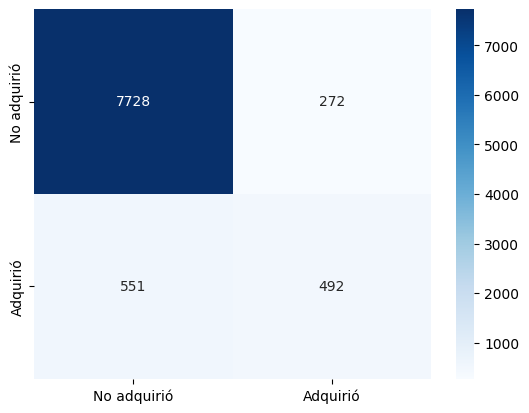

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No adquirió", "Adquirió"], yticklabels=["No adquirió", "Adquirió"])

In [52]:
df_predictions = X_test.copy()

In [53]:
X_test

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
26074,33,admin.,single,secondary,no,0.0,yes,no,cellular,19,nov,85,2,-1,0,unknown
28661,27,management,single,primary,yes,13.0,no,no,cellular,30,jan,475,3,-1,0,unknown
28383,30,admin.,single,secondary,no,60.0,no,no,cellular,29,jan,55,2,-1,0,unknown
23964,40,management,single,tertiary,no,185.0,no,no,cellular,29,aug,173,4,-1,0,unknown
29574,33,student,single,secondary,no,1883.0,yes,no,cellular,3,feb,121,5,256,1,failure
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5772,32,blue-collar,single,primary,no,405.0,yes,no,unknown,26,may,200,1,-1,0,unknown
22370,35,technician,divorced,secondary,no,308.0,no,no,cellular,22,aug,77,2,-1,0,unknown
39261,47,services,married,secondary,no,49.0,yes,no,cellular,18,may,250,4,-1,0,unknown
34616,53,admin.,divorced,secondary,no,0.0,yes,no,cellular,5,may,246,1,344,1,failure


In [57]:
df_predictions["adquiere_real"] = y_test.values

df_predictions["prediction_label"] = y_pred

df_predictions["prediction_score"] = y_pred_proba

print(df_predictions[['age', 'education','housing','adquiere_real', 'prediction_label', 'prediction_score']].sample(10))

       age  education housing adquiere_real prediction_label  prediction_score
40406   45    unknown      no            no               no          0.076935
39261   47  secondary     yes            no               no          0.035422
20597   30   tertiary     yes            no               no          0.016556
38546   26  secondary     yes            no               no          0.001251
6133    26  secondary     yes            no               no          0.007738
29943   28  secondary      no            no               no          0.157928
19495   47   tertiary      no            no               no          0.109741
27097   34  secondary     yes            no               no          0.025988
41527   32   tertiary     yes            no               no          0.386814
12077   58   tertiary      no            no               no          0.001475


Guardamos el modelo 1

In [55]:
full_pipeline = SKLearnPipeline(steps=[
    ("preprocessor", preprocessor),
    ("automl", automl.model)
])

print(full_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age', 'balance', 'day',
                                                   'duration', 'campaign',
                                                   'pdays', 'previous']),
                                                 ('ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categories=[['tertiary',
                                                                          

In [56]:
import joblib 

model_filename = DATA_DIR / "xgb_flaml_automl_model.joblib"
joblib.dump(full_pipeline, model_filename)

['C:\\Users\\aical\\Documents\\JM_SD_SC_marketing_bancario\\datos\\xgb_flaml_automl_model.joblib']